# Shir's boards — embedding inspection

Same nine methods and locked **0.4** / `candidate_limit=20000` as the official series, but the 25 cards and roles come from `data/boards/shirs_boards.json` (not our intersection sampler).

Styles: `dual_0` (no dual cards), `natural` (mix), `dual_100` (all dual). 30 boards each.

OOV vs Word2Vec ∩ fastText (`shir_v1`):

- **Red OOV** → `oov_loss` (game not played).
- **Assassin OOV** (no red OOV) → play; tagged **unfair** (assassin cannot be hit or enter `max_bad`).
- **Blue / civilian OOV** → play; those cards skipped in cosine and cannot be guessed.

Logs: `results/embedding/shir/` (not mixed with the official folder). Re-run all cells after new logs.

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "codenames" / "board.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import codenames.summarize_embedding as summarize_embedding

importlib.reload(summarize_embedding)
from codenames.logging_io import SHIR_RESULTS_DIR
from codenames.summarize_embedding import (
    METHOD_LABELS,
    OFFICIAL_MODELS,
    SHIR_EXPECTED,
    SHIR_STYLES,
    load_embedding_games,
    shir_series,
)

METHODS = [METHOD_LABELS[m] for m in OFFICIAL_MODELS]
BOARDS = list(SHIR_STYLES)
WIN_COLOR = "#2ca02c"
UNFAIR_COLOR = "#ffbf00"
OOV_COLOR = "#ff7f0e"
ASSASSIN_COLOR = "#d62728"
OTHER_COLOR = "#7f7f7f"

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

df = pd.DataFrame(shir_series(load_embedding_games(SHIR_RESULTS_DIR)))
print("repo:", ROOT)
print("logs:", SHIR_RESULTS_DIR)
print("shir games logged:", len(df), "/", SHIR_EXPECTED)
if not df.empty:
    df["method"] = pd.Categorical(df["method"], categories=METHODS, ordered=True)
    df["board"] = pd.Categorical(df["board"], categories=BOARDS, ordered=True)

repo: /Users/sharons/personal-projects/nlp_project_reichman
logs: /Users/sharons/personal-projects/nlp_project_reichman/results/embedding/shir
shir games logged: 810 / 810


## Coverage

Expected 30 games per method × style. `oov_loss` still counts as a logged game.

In [2]:
def show_table(frame: pd.DataFrame) -> None:
    display(HTML(f'<div style="max-height:none;overflow:visible">{frame.to_html(escape=True)}</div>'))


if df.empty:
    print("No Shir games yet. Run: caffeinate -dims bash scripts/run_shir_official.sh")
else:
    coverage = (
        df.groupby(["method", "board"], observed=False)
        .size()
        .unstack("board")
        .reindex(index=METHODS, columns=BOARDS)
        .fillna(0)
        .astype(int)
    )
    display(Markdown("Games logged (max 30)"))
    show_table(coverage)
    display(Markdown("OOV red losses / assassin-OOV (unfair) / blue-OOV boards"))
    flags = (
        df.groupby(["method", "board"], observed=False)[
            ["oov_red_loss", "assassin_oov_unfair", "oov_blue", "oov_civilian"]
        ]
        .sum()
        .astype(int)
    )
    show_table(flags)

Games logged (max 30)

board,dual_0,natural,dual_100
method,,,
W2V→W2V,30,30,30
FT→FT,30,30,30
W2V→FT,30,30,30
FT→W2V,30,30,30
concat→FT,30,30,30
concat→W2V,30,30,30
W2V→concat,30,30,30
FT→concat,30,30,30
concat→concat,30,30,30


OOV red losses / assassin-OOV (unfair) / blue-OOV boards

## Wins and losses by method

Stacked: fair win, unfair win (assassin OOV), OOV red loss, assassin hit, other.

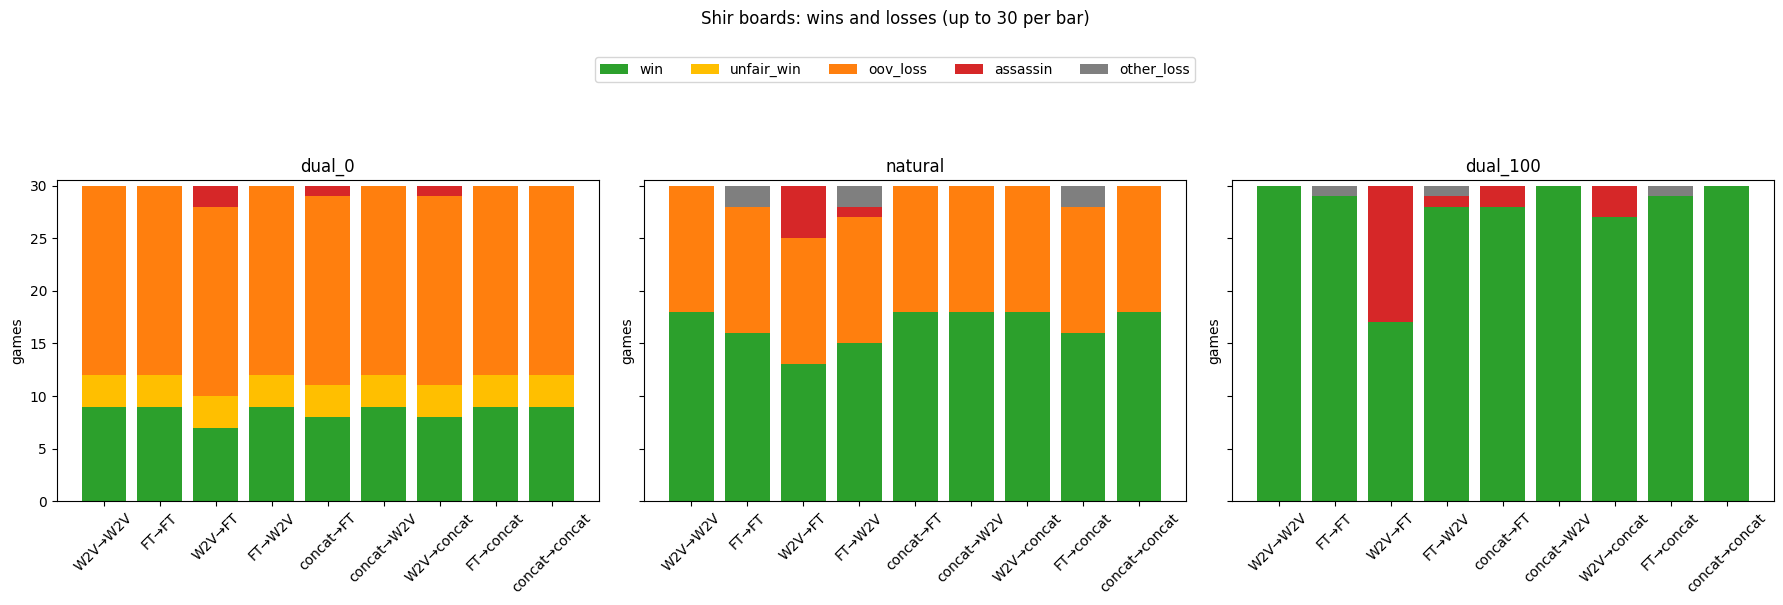

In [3]:
if df.empty:
    print("No Shir games yet.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    kinds = ["win", "unfair_win", "oov_loss", "assassin", "other_loss"]
    colors = {
        "win": WIN_COLOR,
        "unfair_win": UNFAIR_COLOR,
        "oov_loss": OOV_COLOR,
        "assassin": ASSASSIN_COLOR,
        "other_loss": OTHER_COLOR,
    }
    for ax, board in zip(axes, BOARDS):
        sub = df[df["board"] == board]
        counts = (
            sub.groupby(["method", "loss_kind"], observed=False)
            .size()
            .unstack("loss_kind")
            .reindex(index=METHODS, columns=kinds)
            .fillna(0)
        )
        bottom = None
        for kind in kinds:
            vals = counts[kind] if kind in counts.columns else 0
            ax.bar(METHODS, vals, bottom=bottom, color=colors[kind], label=kind)
            bottom = vals if bottom is None else bottom + vals
        ax.set_title(board)
        ax.set_ylim(0, 30.5)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylabel("games")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.12))
    fig.suptitle("Shir boards: wins and losses (up to 30 per bar)", y=1.20)
    fig.tight_layout()
    plt.show()

## Mean turns among wins

Includes unfair assassin-OOV wins. Fair-only means are in the second table.

Mean turns on all wins (including assassin-OOV unfair)

board,dual_0,natural,dual_100
method,,,
W2V→W2V,3.33,3.17,3.47
FT→FT,7.67,7.81,8.07
W2V→FT,6.70,6.23,6.71
FT→W2V,9.25,9.67,9.21
concat→FT,5.91,5.89,6.68
concat→W2V,6.00,6.06,6.53
W2V→concat,3.91,3.89,4.22
FT→concat,8.00,8.25,8.45
concat→concat,5.42,5.50,6.07


Mean turns on fair wins only

board,dual_0,natural,dual_100
method,,,
W2V→W2V,3.33,3.17,3.47
FT→FT,7.56,7.81,8.07
W2V→FT,6.43,6.23,6.71
FT→W2V,9.00,9.67,9.21
concat→FT,5.75,5.89,6.68
concat→W2V,5.78,6.06,6.53
W2V→concat,3.88,3.89,4.22
FT→concat,7.89,8.25,8.45
concat→concat,5.33,5.50,6.07


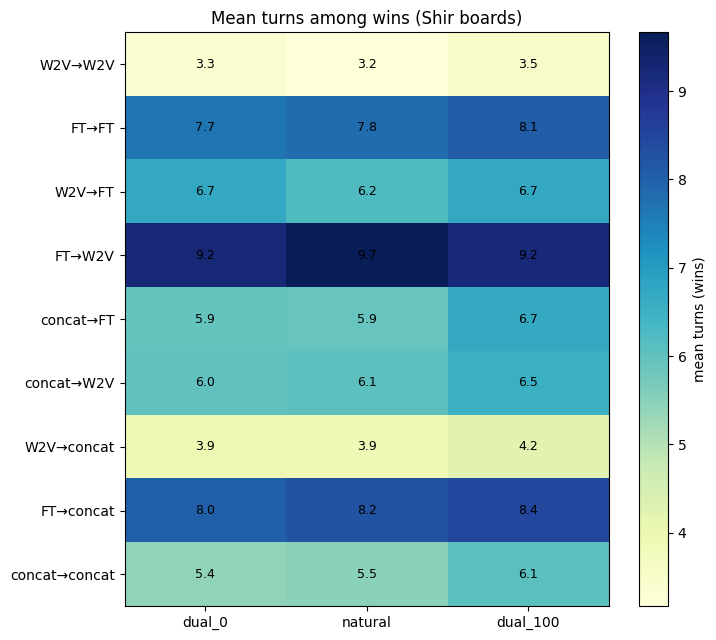

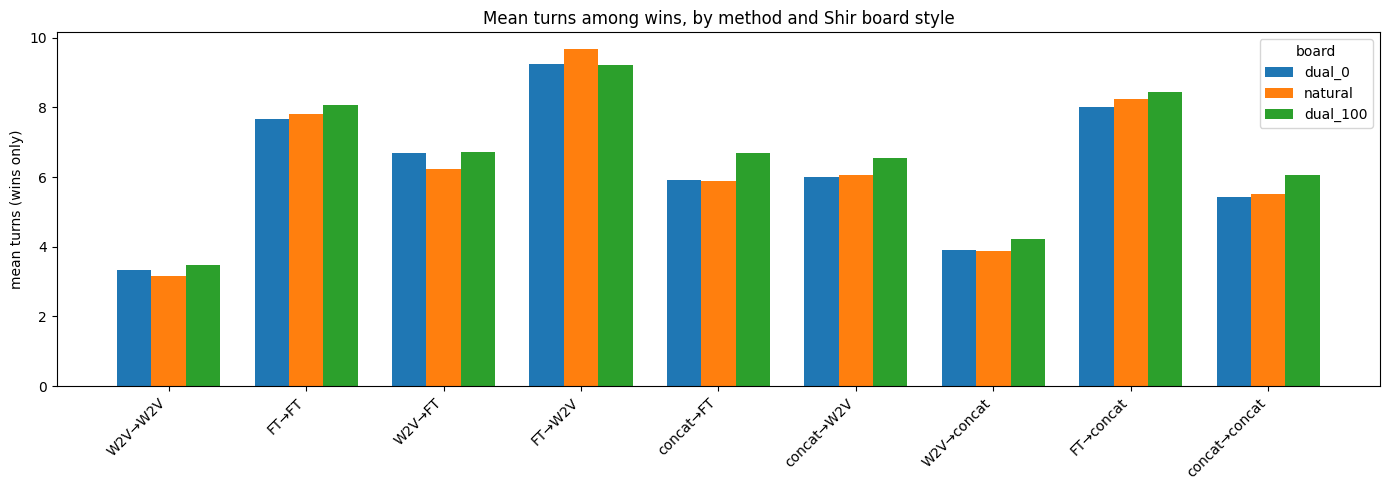

In [4]:
if df.empty or not df["win"].any():
    print("No wins logged yet.")
else:
    won = df[df["win"]]
    mean_turns = (
        won.groupby(["method", "board"], observed=False)["turns"]
        .mean()
        .unstack("board")
        .reindex(index=METHODS, columns=BOARDS)
    )
    display(Markdown("Mean turns on all wins (including assassin-OOV unfair)"))
    show_table(mean_turns.round(2))
    fair = df[df["fair_win"]]
    if fair.empty:
        print("No fair wins.")
    else:
        fair_turns = (
            fair.groupby(["method", "board"], observed=False)["turns"]
            .mean()
            .unstack("board")
            .reindex(index=METHODS, columns=BOARDS)
        )
        display(Markdown("Mean turns on fair wins only"))
        show_table(fair_turns.round(2))

    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    grid = mean_turns.to_numpy(dtype=float)
    im = ax.imshow(grid, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(range(len(BOARDS)), BOARDS)
    ax.set_yticks(range(len(METHODS)), METHODS)
    ax.set_title("Mean turns among wins (Shir boards)")
    for i in range(len(METHODS)):
        for j in range(len(BOARDS)):
            val = grid[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, label="mean turns (wins)")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(METHODS))
    width = 0.25
    for i, board in enumerate(BOARDS):
        vals = (
            mean_turns[board].to_numpy(dtype=float)
            if board in mean_turns.columns
            else [float("nan")] * len(METHODS)
        )
        ax.bar([p + (i - 1) * width for p in x], vals, width=width, label=board)
    ax.set_xticks(list(x), METHODS, rotation=45, ha="right")
    ax.set_ylabel("mean turns (wins only)")
    ax.set_title("Mean turns among wins, by method and Shir board style")
    ax.legend(title="board")
    fig.tight_layout()
    plt.show()

## OOV word list per logged game

In [5]:
if df.empty:
    print("No Shir games yet.")
else:
    tagged = df[df["oov_words"] != ""][
        ["method", "board", "seed", "outcome", "oov_red_loss", "assassin_oov_unfair", "oov_blue", "oov_civilian", "oov_words"]
    ]
    display(Markdown("Games with at least one intersection-OOV card (one row per method)"))
    show_table(tagged.sort_values(["board", "seed", "method"]))

Games with at least one intersection-OOV card (one row per method)

,method,board,seed,outcome,oov_red_loss,assassin_oov_unfair,oov_blue,oov_civilian,oov_words
0,W2V→W2V,dual_0,0,oov_loss,True,False,False,True,"בית-כנסת,אפיקומן"
1,FT→FT,dual_0,0,oov_loss,True,False,False,True,"בית-כנסת,אפיקומן"
2,W2V→FT,dual_0,0,oov_loss,True,False,False,True,"בית-כנסת,אפיקומן"
3,FT→W2V,dual_0,0,oov_loss,True,False,False,True,"בית-כנסת,אפיקומן"
5,concat→FT,dual_0,0,oov_loss,True,False,False,True,"בית-כנסת,אפיקומן"
4,concat→W2V,dual_0,0,oov_loss,True,False,False,True,"בית-כנסת,אפיקומן"
6,W2V→concat,dual_0,0,oov_loss,True,False,False,True,"בית-כנסת,אפיקומן"
7,FT→concat,dual_0,0,oov_loss,True,False,False,True,"בית-כנסת,אפיקומן"
8,concat→concat,dual_0,0,oov_loss,True,False,False,True,"בית-כנסת,אפיקומן"
594,W2V→W2V,dual_0,2,oov_loss,True,False,True,True,"רוח-רפאים,חד-קרן,גורד-שחקים,תל-אביב,לוויין"
